# Experiment 2A — Future portfolio-loss prediction

Saved target histories, model comparisons, forecast paths and capacity summaries for the 1-, 5- and 10-day horizons. The Choquet comparison includes 1-additive and 2-additive models, their scaled-q counterparts, and L1 versions of both 2-additive specifications; scaled-q models supplement rather than replace the ordinary models. The experiment also compares a conventional MLP with a neural benchmark that uses a supervised 2-additive Choquet input layer before its tanh network. The Choquet model aggregator is a separate benchmark learned only from the validation predictions of classical models, including the conventional MLP; Choquet-based models are never used as its inputs.

In [1]:
from IPython.display import Image, Markdown, display
from mwc_experiments.reporting import (
    load_result_comparison, load_result_table, result_figure_path,
)

## Predictors and forecast targets

## Fixed versus rolling_5y comparison

The table below keeps every temporal structure and clipping mode in a separate immutable run. Rows are labelled by run mode and must not be pooled as observations from one common test sample.

In [ ]:
display(load_result_comparison('experiment_2a_all_metrics.csv', experiment='future_loss', index_col=[0, 1]))

### Predictor dependence
Check redundancy and clusters among risk indicators before comparing nonlinear models.

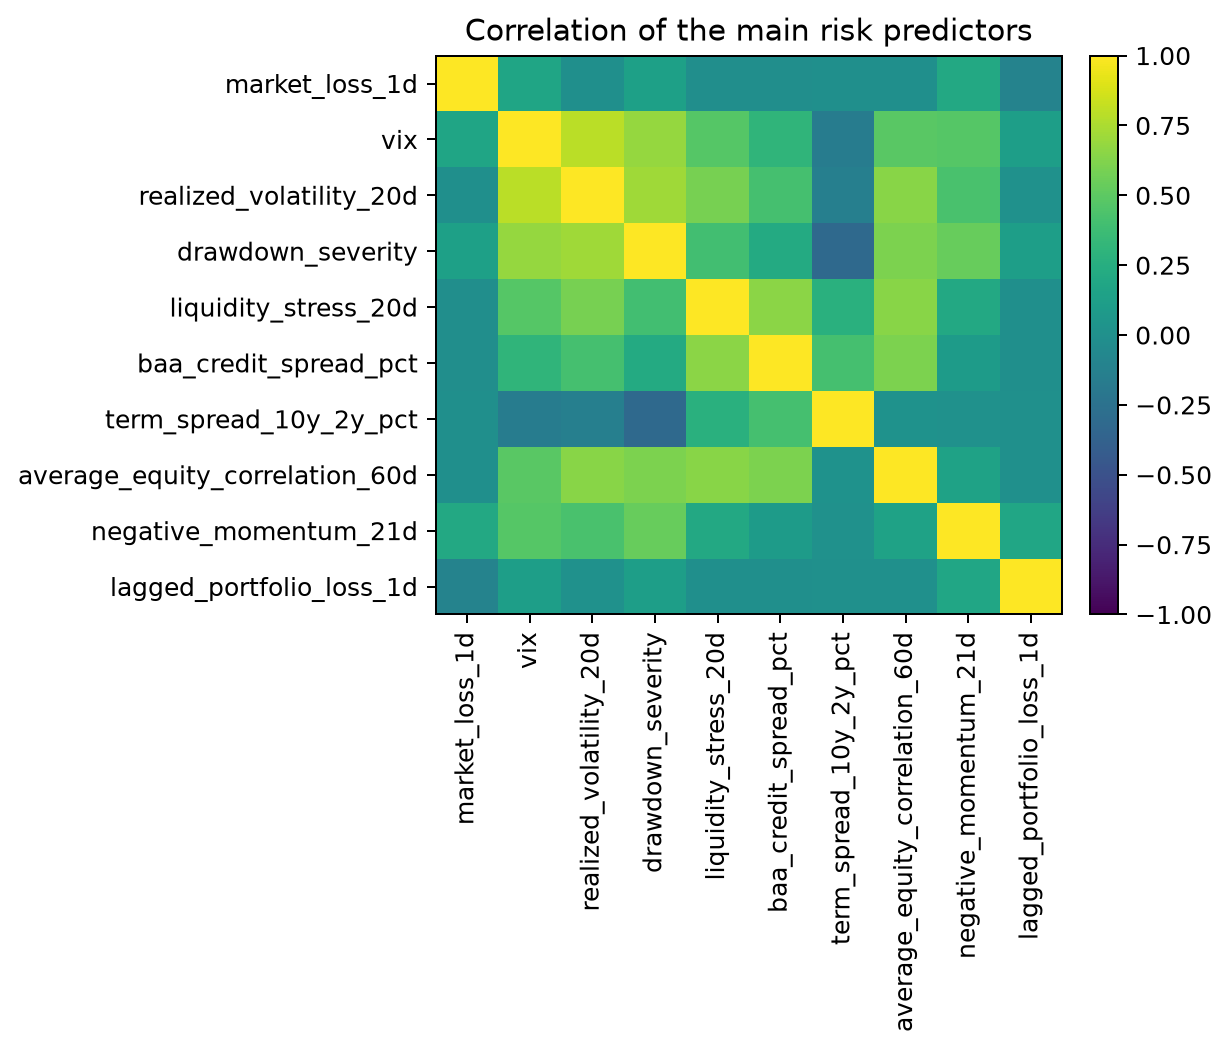

### Forecast-target histories
Compare the scale and persistence of future losses across 1-, 5- and 10-day horizons.

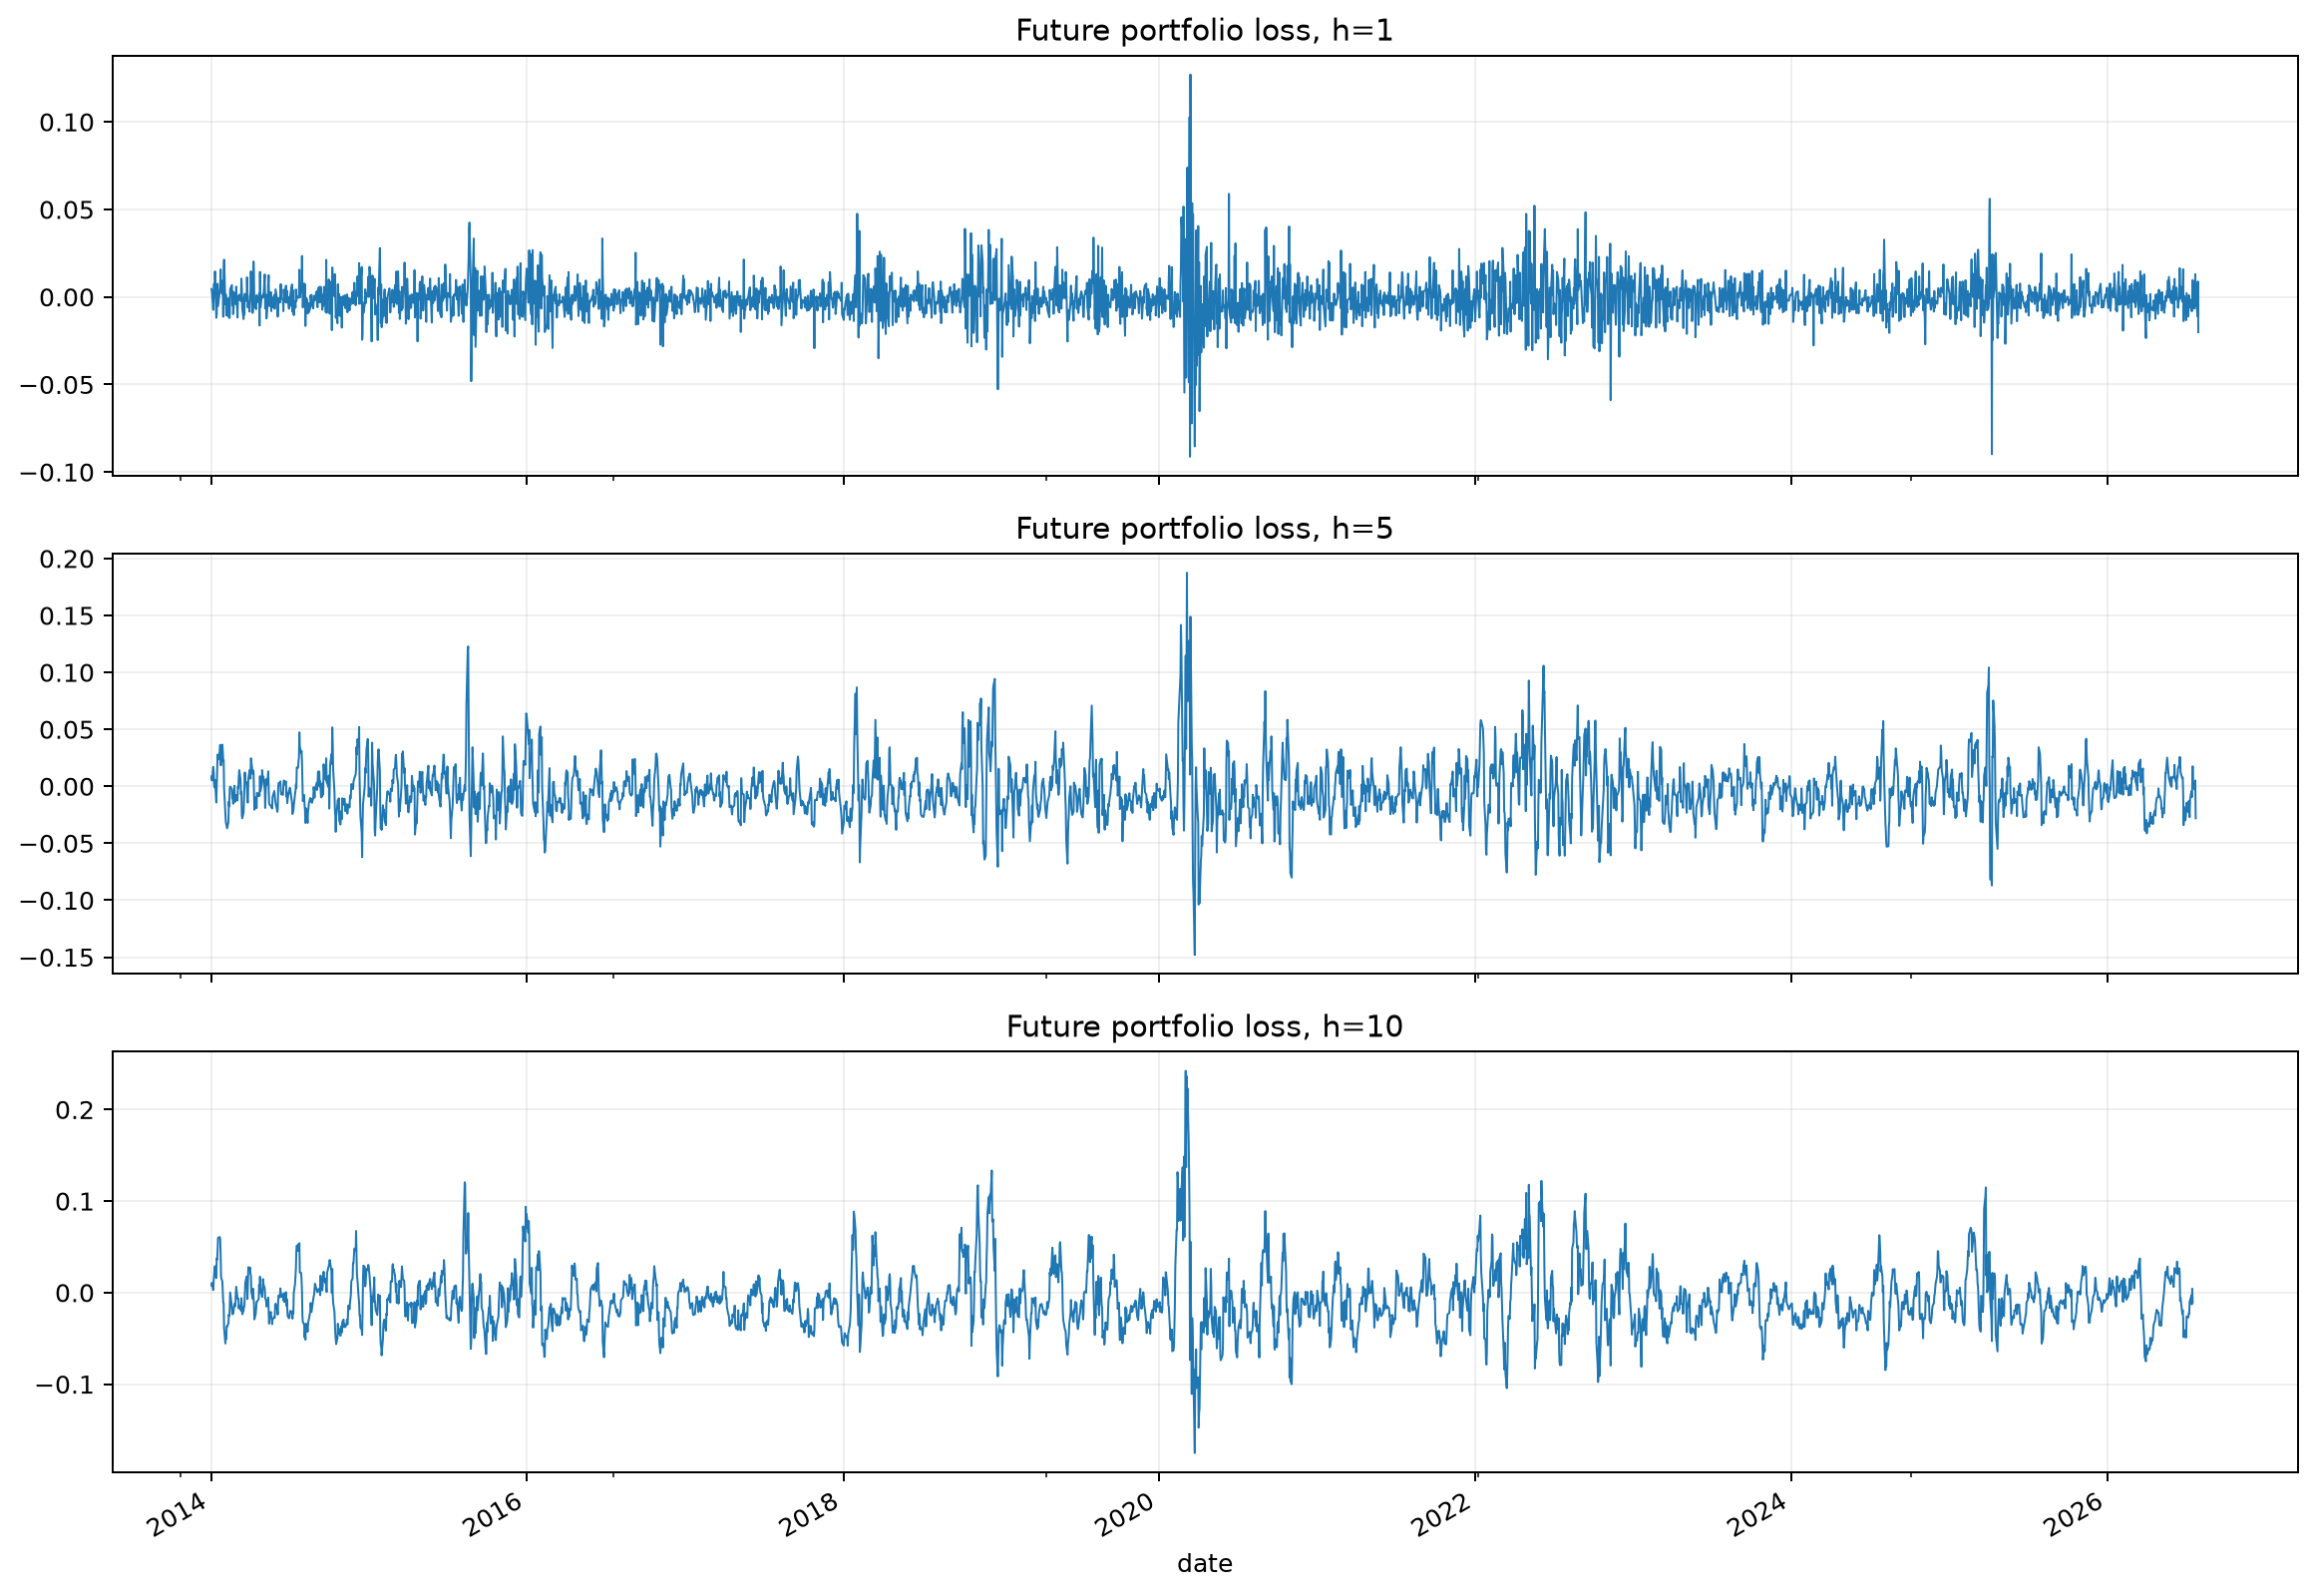

In [2]:
display(Markdown("### Predictor dependence\nCheck redundancy and clusters among risk indicators before comparing nonlinear models."))
display(Image(filename=result_figure_path("experiment_2a_predictor_correlation.png")))
display(Markdown("### Forecast-target histories\nCompare the scale and persistence of future losses across 1-, 5- and 10-day horizons."))
display(Image(filename=result_figure_path("experiment_2a_future_loss_history.png")))

## Rolling out-of-sample model comparison

Every annual OOS block is predicted after repeating training-window preprocessing, hyperparameter selection and refitting using past data only. Final metrics concatenate all rolling OOS predictions. The aggregation capacity is fitted on the chronological inner-validation block and is evaluated only on the following OOS block; its validation score is therefore descriptive rather than a selection score comparable with the base candidates.

### Concatenated OOS metrics by horizon
These are the final rankings after joining every annual walk-forward prediction block.

,MSE,RMSE,MAE,Tail-weighted MAE,OOS R2,Correlation,validation RMSE,selection runtime seconds,refit runtime seconds,parameter count,OOS folds
model,,,,,,,,,,,
Historical mean,0.000174,0.013179,0.008581,0.012225,0.000000,-0.025839,0.012081,0.031630,0.020309,NaN,7
Lasso,0.000174,0.013198,0.008604,0.012234,-0.002973,0.000077,0.012055,0.133333,0.024387,11.0,7
Monotone linear,0.000174,0.013208,0.008606,0.012228,-0.004414,-0.021465,0.012135,0.045948,0.028963,11.0,7
Elastic net,0.000175,0.013235,0.008679,0.012304,-0.008628,0.005207,0.012121,0.331623,0.024254,11.0,7
Random forest,0.000176,0.013277,0.008553,0.012301,-0.014926,0.002581,0.012054,12.196812,1.599891,NaN,7
Gradient boosting,0.000180,0.013409,0.008792,0.012255,-0.035304,0.050820,0.012277,6.948049,0.497434,NaN,7
Ridge,0.000180,0.013428,0.008964,0.012384,-0.038131,0.016304,0.012505,0.133584,0.023322,11.0,7
OLS,0.000181,0.013445,0.008983,0.012395,-0.040803,0.016198,0.012549,0.034296,0.025529,11.0,7
OLS oriented,0.000181,0.013445,0.008983,0.012395,-0.040803,0.016198,0.012549,0.045692,0.030499,11.0,7


,MSE,RMSE,MAE,Tail-weighted MAE,OOS R2,Correlation,validation RMSE,selection runtime seconds,refit runtime seconds,parameter count,OOS folds
model,,,,,,,,,,,
Historical mean,0.000686,0.026190,0.018396,0.025942,0.000000,-0.060154,0.024528,0.029738,0.020637,NaN,7
Monotone linear,0.000687,0.026209,0.018423,0.025950,-0.001472,-0.087836,0.024601,0.044343,0.029025,11.0,7
Elastic net,0.000734,0.027092,0.019745,0.026554,-0.070090,0.005495,0.025389,0.299901,0.022647,11.0,7
Lasso,0.000747,0.027336,0.019854,0.026805,-0.089499,-0.019245,0.024294,0.137220,0.022742,11.0,7
Gradient boosting,0.000752,0.027414,0.019374,0.025991,-0.095715,0.086071,0.027838,5.482116,0.488307,NaN,7
Ridge,0.000761,0.027593,0.020428,0.026609,-0.110029,0.036962,0.027109,0.129834,0.023184,11.0,7
OLS oriented,0.000768,0.027707,0.020547,0.026654,-0.119207,0.037143,0.027382,0.044524,0.030445,11.0,7
OLS,0.000768,0.027707,0.020547,0.026654,-0.119207,0.037143,0.027382,0.033991,0.025671,11.0,7
Random forest,0.000771,0.027773,0.019938,0.027092,-0.124603,0.003504,0.025351,12.117089,1.716602,NaN,7


,MSE,RMSE,MAE,Tail-weighted MAE,OOS R2,Correlation,validation RMSE,selection runtime seconds,refit runtime seconds,parameter count,OOS folds
model,,,,,,,,,,,
Historical mean,0.001312,0.036222,0.025614,0.036656,0.000000,-0.077755,0.033445,0.030585,0.021422,NaN,7
Monotone linear,0.001344,0.036664,0.026541,0.036468,-0.024546,0.010790,0.034912,0.046130,0.029299,11.0,7
Random forest,0.001403,0.037458,0.026607,0.037178,-0.069427,0.044487,0.035202,12.369951,1.747223,NaN,7
Elastic net,0.001488,0.038570,0.028796,0.037961,-0.133877,0.016280,0.036926,0.308300,0.023585,11.0,7
Gradient boosting,0.001504,0.038780,0.027883,0.036472,-0.146232,0.147075,0.038915,5.502857,0.575019,NaN,7
Lasso,0.001553,0.039411,0.029123,0.038981,-0.183821,-0.024482,0.032741,0.136794,0.023132,11.0,7
Ridge,0.001575,0.039692,0.030052,0.038159,-0.200796,0.039985,0.039168,0.131719,0.022732,11.0,7
Choquet 2-additive,0.001592,0.039903,0.028835,0.035715,-0.213598,0.028151,0.040963,4.500396,4.713458,56.0,7
OLS,0.001593,0.039909,0.030274,0.038247,-0.213954,0.040666,0.039681,0.034870,0.024405,11.0,7


### Walk-forward chronology and fold performance
Audit the moving estimation windows and check whether aggregate rankings are stable across years.

...

,MSE,RMSE,MAE,Tail-weighted MAE,OOS R2,Correlation,validation RMSE,selection runtime seconds,refit runtime seconds,parameter count,OOS folds
model,,,,,,,,,,,
Monotone linear,0.001344,0.036664,0.026541,0.036468,-0.024546,0.010790,0.034912,0.046130,0.029299,11.0,7
Choquet 2-additive,0.001592,0.039903,0.028835,0.035715,-0.213598,0.028151,0.040963,4.500396,4.713458,56.0,7
OLS,0.001593,0.039909,0.030274,0.038247,-0.213954,0.040666,0.039681,0.034870,0.024405,11.0,7
OLS oriented,0.001593,0.039909,0.030274,0.038247,-0.213954,0.040666,0.039681,0.044803,0.030416,11.0,7
Choquet 1-additive,0.001646,0.040570,0.029392,0.035909,-0.254517,0.025469,0.042155,1.244853,0.981300,11.0,7


### Validation-stress sensitivity
Test whether the stressed validation episode changes selected parameters and later performance.

validation observations  \
regime              model                                            
excluding 2020-2021 Choquet 1-additive                         503   
                    Choquet 2-additive                         503   
                    Choquet 2-additive L1                      503   
                    Elastic net                                503   
                    Explicit interactions                      503   
                    Gradient boosting                          503   
                    Historical mean                            503   
                    Lasso                                      503   
                    MLP                                        503   
                    Monotone linear                            503   
                    OLS                                        503   
                    OLS oriented                               503   
                    Random forest                              503   
                    Ridge                                      503   
including stress    Choquet 1-additive                        1003   
                    Choquet 2-additive                        1003   
                    Choquet 2-additive L1                     1003   
                    Elastic net                               1003   
                    Explicit interactions                     1003   
                    Gradient boosting                         1003   
                    Historical mean                           1003   
                    Lasso                                     1003   
                    MLP                                       1003   
                    Monotone linear                           1003   
                    OLS                                       1003   
                    OLS oriented                              1003   
                    Random forest                             1003   
                    Ridge                                     1003   

                                           validation folds  validation RMSE  \
regime              model                                                      
excluding 2020-2021 Choquet 1-additive                    4         0.037737   
                    Choquet 2-additive                    4         0.042458   
                    Choquet 2-additive L1                 4         0.037615   
                    Elastic net                           4         0.026970   
                    Explicit interactions                 4         0.051236   
                    Gradient boosting                     4         0.028002   
                    Historical mean                       4         0.024594   
                    Lasso                                 4         0.024594   
                    MLP                                   4         0.112604   
                    Monotone linear                       4         0.029849   
                    OLS                                   4         0.032756   
                    OLS oriented                          4         0.032756   
                    Random forest                         4         0.026736   
                    Ridge                                 4         0.032331   
including stress    Choquet 1-additive                    4         0.035119   
                    Choquet 2-additive                    4         0.037692   
                    Choquet 2-additive L1                 4         0.035063   
                    Elastic net                           4         0.029271   
                    Explicit interactions                 4         0.043458   
                    Gradient boosting                     4         0.030366   
                    Historical mean                       4         0.028191   
                    Lasso                                 4         0.028191   
                    ML

,validation-selected model,selected validation RMSE,selected model test RMSE,best test model,best test RMSE,selection regret
regime,,,,,,
excluding 2020-2021,Historical mean,0.024594,0.023544,Elastic net,0.02348,0.000064
including stress,Historical mean,0.028191,0.023544,Elastic net,0.02348,0.000064


### Cross-horizon RMSE
The figure shows how relative model performance changes as the forecast horizon lengthens.

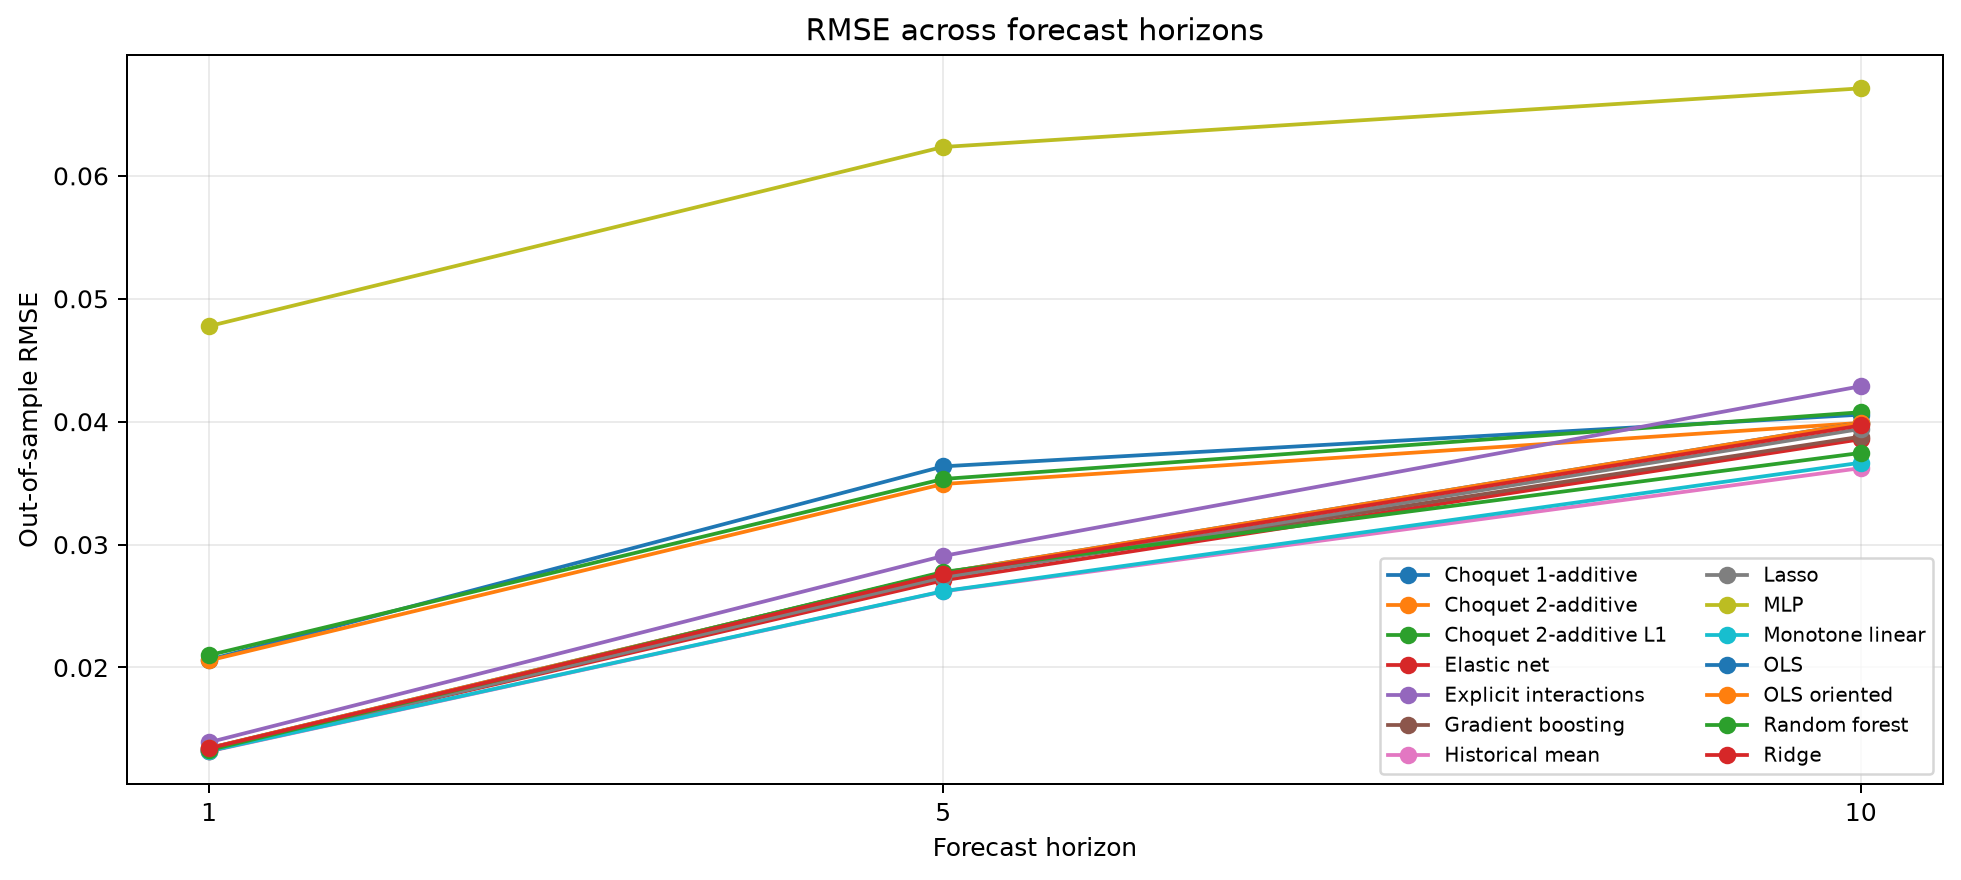

In [3]:
display(Markdown("### Concatenated OOS metrics by horizon\nThese are the final rankings after joining every annual walk-forward prediction block."))
display(load_result_table("experiment_2a_regression_metrics_h1.csv", index_col=0))
display(load_result_table("experiment_2a_regression_metrics_h5.csv", index_col=0))
display(load_result_table("experiment_2a_regression_metrics_h10.csv", index_col=0))
display(Markdown("### Walk-forward chronology and fold performance\nAudit the moving estimation windows and check whether aggregate rankings are stable across years."))
display(load_result_table("experiment_2a_walk_forward_folds_h5.csv", index_col=0))
display(load_result_table("experiment_2a_walk_forward_metrics_h5.csv", index_col=[0, 1]))
display(Markdown("### Re-estimation history\nConfirm that orientations and Choquet importance are newly learned in every window rather than carried forward."))
display(load_result_table("experiment_2a_orientation_history_h5.csv", index_col=[0, 1, 2]))
display(load_result_table("experiment_2a_shapley_history_h5.csv", index_col=[0, 1, 2]))
display(Markdown("### Validation-selected Choquet specification\nIdentify the capacity order selected without consulting any OOS block."))
display(load_result_table("experiment_2a_validation_selected_choquet_h1.csv", index_col=0))
display(load_result_table("experiment_2a_validation_selected_choquet_h5.csv", index_col=0))
display(load_result_table("experiment_2a_validation_selected_choquet_h10.csv", index_col=0))
display(Markdown("### Learned q scales by horizon\nInspect the overall response scale estimated in every fold for scaled-q models; ordinary Choquet rows are intentionally omitted here."))
display(Markdown("#### Horizon 1 day"))
display(load_result_table("experiment_2a_q_scales_h1.csv", index_col=[0, 1]))
display(Markdown("#### Horizon 5 days"))
display(load_result_table("experiment_2a_q_scales_h5.csv", index_col=[0, 1]))
display(Markdown("#### Horizon 10 days"))
display(load_result_table("experiment_2a_q_scales_h10.csv", index_col=[0, 1]))
display(Markdown("### Orientation ablation\nSeparate gains from sign orientation from gains due to monotonicity and Choquet interactions."))
display(load_result_table("experiment_2a_orientation_ablation_h1.csv", index_col=0))
display(load_result_table("experiment_2a_orientation_ablation_h5.csv", index_col=0))
display(load_result_table("experiment_2a_orientation_ablation_h10.csv", index_col=0))
display(Markdown("### Validation-stress sensitivity\nTest whether the stressed validation episode changes selected parameters and later performance."))
display(load_result_table("experiment_2a_validation_stress_comparison_h5.csv", index_col=[0, 1]))
display(load_result_table("experiment_2a_validation_stress_selection_summary_h5.csv", index_col=0))
display(Markdown("### Cross-horizon RMSE\nThe figure shows how relative model performance changes as the forecast horizon lengthens."))
display(Image(filename=result_figure_path("experiment_2a_rmse_across_horizons.png")))

## Forecast paths, empirical extremes and high-loss performance

### Conditional high-loss performance
Focus on observations with the largest realized losses rather than average OOS accuracy.

,MSE,RMSE,MAE,Tail-weighted MAE,OOS R2,Correlation
Explicit interactions,0.002903,0.053876,0.042999,0.060234,-2.928999,-0.096531
OLS,0.003092,0.055604,0.046973,0.063933,-3.185109,-0.155875
OLS oriented,0.003092,0.055604,0.046973,0.063933,-3.185109,-0.155875
Ridge,0.003101,0.055691,0.047173,0.064081,-3.198236,-0.158328
Elastic net,0.003243,0.056947,0.049209,0.065757,-3.389758,-0.236045
Lasso,0.003287,0.057331,0.049932,0.066074,-3.449219,-0.126448
Monotone linear,0.003334,0.057744,0.050994,0.066819,-3.513414,0.179751
Historical mean,0.003345,0.057833,0.051049,0.066927,-3.527349,0.013866
Gradient boosting,0.003358,0.057950,0.048006,0.065765,-3.545724,-0.215392
Random forest,0.003496,0.059129,0.050893,0.067849,-3.732614,-0.223453


### Common empirical-stress scenario
Verify the shared stress definition, then compare every model on exactly the same extreme dates.

,observations,feature-extreme observations,loss-extreme observations,stress observations,stress rate,loss threshold
sample,,,,,,
estimation,1245,112,13,123,0.098795,0.060368
test,139,80,0,80,0.575540,0.060368


,stress observations,MSE,RMSE,MAE,Tail-weighted MAE,OOS R2,Correlation
model,,,,,,,
Gradient boosting,80,0.000182,0.013474,0.010616,0.012239,-0.017890,0.175289
Random forest,80,0.000186,0.013640,0.010882,0.013514,-0.043131,-0.062870
Historical mean,80,0.000193,0.013888,0.011120,0.014298,-0.081464,NaN
Lasso,80,0.000198,0.014085,0.011301,0.014545,-0.112343,-0.125520
Monotone linear,80,0.000199,0.014107,0.011277,0.014587,-0.115829,-0.182900
Elastic net,80,0.000207,0.014380,0.011543,0.014863,-0.159441,-0.202368
Choquet 2-additive L1,80,0.000274,0.016566,0.012551,0.017363,-0.538804,0.114641
Ridge,80,0.000278,0.016687,0.013532,0.017401,-0.561380,-0.171686
Choquet 1-additive,80,0.000279,0.016690,0.012677,0.017545,-0.561858,0.113417


...

,fit observations,extreme fit observations removed,extreme fit rate,test observations,stress test observations,full-fit test RMSE,reduced-fit test RMSE,test RMSE change,mean absolute prediction change,maximum absolute prediction change,full-fit stress RMSE,reduced-fit stress RMSE,stress mean absolute prediction change,failure
model,,,,,,,,,,,,,,
OLS,1245,123,0.098795,139,80,0.017718,0.017294,-0.000424,0.000879,0.003127,0.016863,0.016432,0.000868,NaN
Ridge,1245,123,0.098795,139,80,0.017632,0.017237,-0.000396,0.000845,0.003029,0.016687,0.016307,0.000810,NaN
Lasso,1245,123,0.098795,139,80,0.016381,0.016208,-0.000174,0.000669,0.001984,0.014085,0.014105,0.000530,NaN
Monotone linear,1245,123,0.098795,139,80,0.016350,0.016370,0.000020,0.000659,0.000937,0.014107,0.014321,0.000687,NaN
Gradient boosting,1245,123,0.098795,139,80,0.015351,0.016402,0.001051,0.006175,0.018081,0.013474,0.016188,0.008628,NaN
Choquet 1-additive,1245,123,0.098795,139,80,0.018008,0.017598,-0.000411,0.001895,0.009668,0.016690,0.015746,0.001830,NaN
Choquet 2-additive,1245,123,0.098795,139,80,0.019172,0.018335,-0.000837,0.001793,0.007778,0.017638,0.016975,0.001850,NaN
Choquet 2-additive L1,1245,123,0.098795,139,80,0.017926,0.017517,-0.000410,0.001774,0.008765,0.016566,0.015771,0.001734,NaN


### Clipping audit and HAC comparison
Check preprocessing intervention first, then assess forecast-loss differences with serial-correlation-robust inference.

,sample,raw minimum,lower clipping bound,raw maximum,upper clipping bound,below-bound observations,above-bound observations,clipped observations,clipped rate
feature,,,,,,,,,
market_loss_1d,estimation,-0.099863,-0.029264,0.060327,0.037333,7,7,14,0.011245
vix,estimation,11.860000,12.074400,52.330000,37.042800,7,7,14,0.011245
realized_volatility_20d,estimation,0.046348,0.066348,0.470620,0.465502,7,7,14,0.011245
drawdown_severity,estimation,-0.000000,0.000000,0.220018,0.208893,0,7,7,0.005622
liquidity_stress_20d,estimation,0.335199,0.346655,0.736254,0.720060,7,7,14,0.011245
baa_credit_spread_pct,estimation,1.360000,1.392200,2.420000,2.370000,7,6,13,0.010442
term_spread_10y_2y_pct,estimation,-1.080000,-0.990000,1.590000,1.537800,6,7,13,0.010442
average_equity_correlation_60d,estimation,0.024741,0.036017,0.583335,0.560971,7,7,14,0.011245
negative_momentum_21d,estimation,-0.126799,-0.106400,0.164536,0.124450,7,7,14,0.011245


,reference,mean loss difference,standard error,lower 95%,upper 95%,favors model
model,,,,,,
Historical mean,Choquet 2-additive,-0.000534,0.000071,-0.000673,-0.000395,True
Monotone linear,Choquet 2-additive,-0.000533,0.000071,-0.000671,-0.000395,True
Elastic net,Choquet 2-additive,-0.000486,0.000074,-0.000631,-0.000341,True
Lasso,Choquet 2-additive,-0.000473,0.000071,-0.000612,-0.000333,True
Gradient boosting,Choquet 2-additive,-0.000468,0.000082,-0.000629,-0.000307,True
Ridge,Choquet 2-additive,-0.000459,0.000077,-0.000610,-0.000307,True
OLS oriented,Choquet 2-additive,-0.000452,0.000078,-0.000604,-0.000300,True
OLS,Choquet 2-additive,-0.000452,0.000078,-0.000604,-0.000300,True
Random forest,Choquet 2-additive,-0.000449,0.000078,-0.000601,-0.000296,True


### OOS forecast paths
Use the time series to locate when model errors occur and whether they cluster in stress periods.

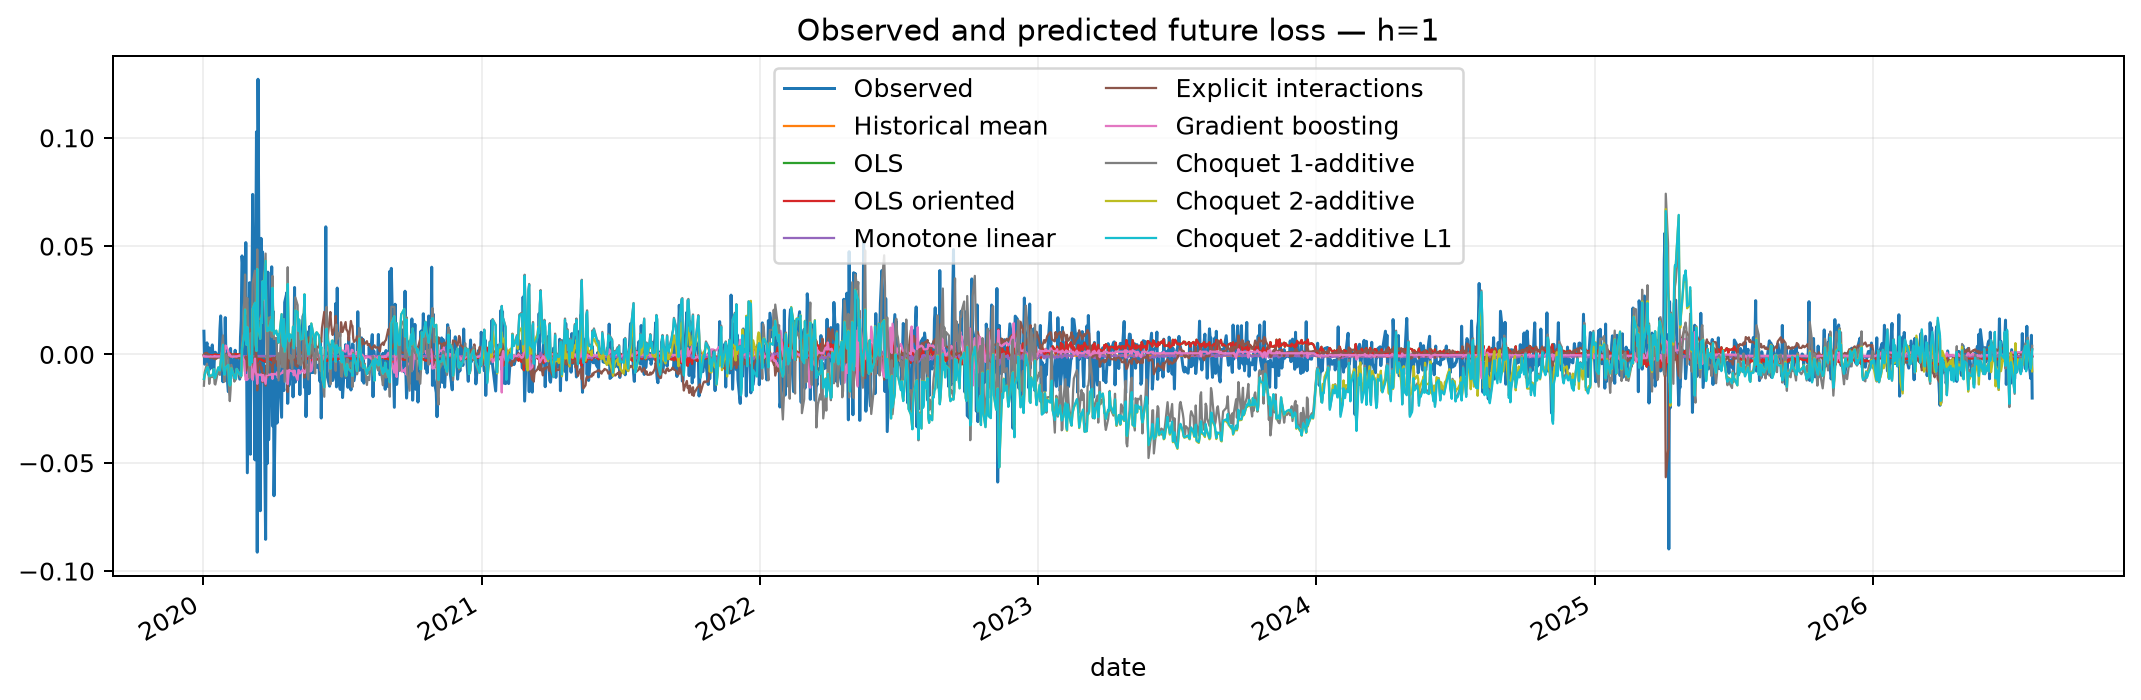

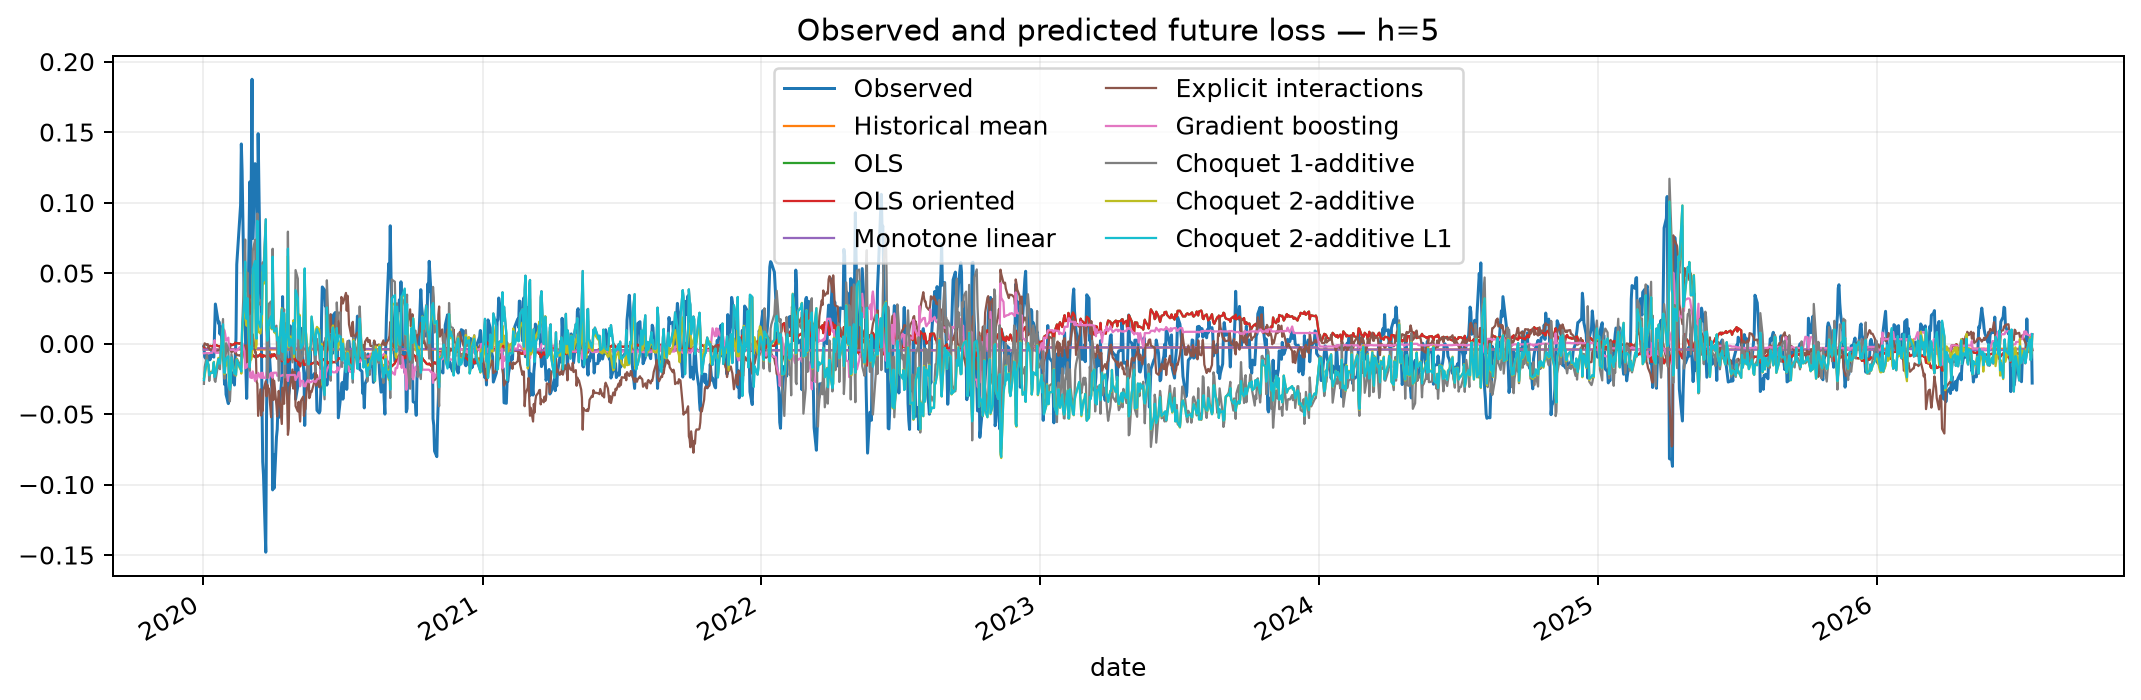

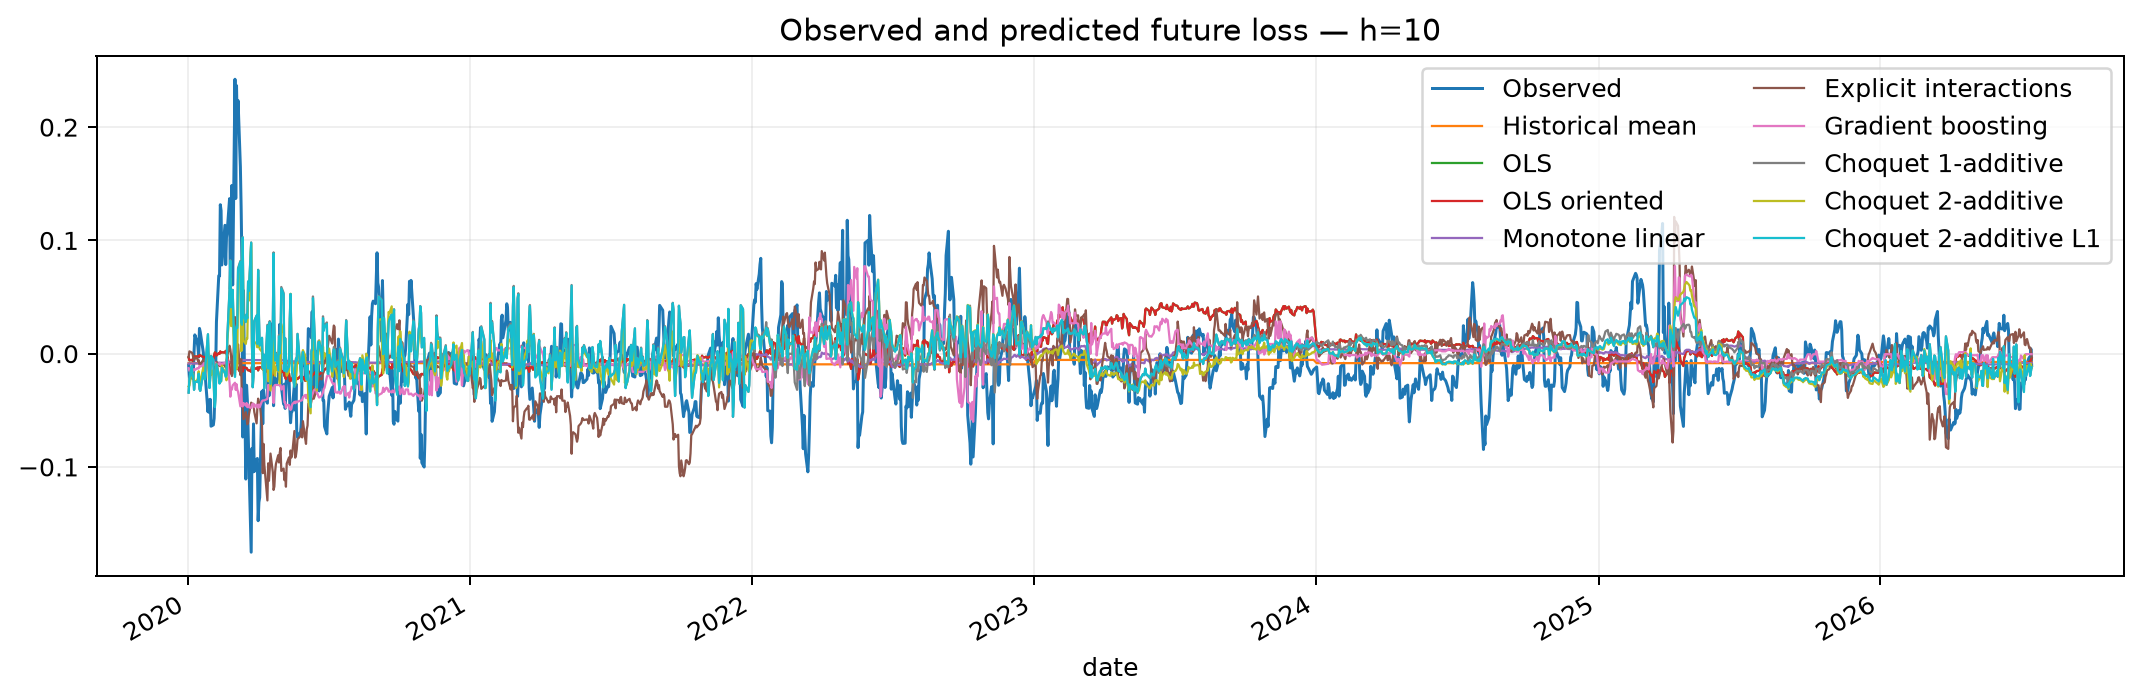

In [4]:
display(Markdown("### Conditional high-loss performance\nFocus on observations with the largest realized losses rather than average OOS accuracy."))
display(load_result_table("experiment_2a_high_loss_metrics_h5.csv", index_col=0))
display(Markdown("### Common empirical-stress scenario\nVerify the shared stress definition, then compare every model on exactly the same extreme dates."))
display(load_result_table("experiment_2a_empirical_stress_audit_h5.csv", index_col=0))
display(load_result_table("experiment_2a_empirical_stress_metrics_h5.csv", index_col=0))
display(Markdown("### Estimation robustness to extremes\nCompare fits with and without extreme training observations while holding selected hyperparameters fixed."))
display(load_result_table("experiment_2a_extreme_estimation_robustness_h5.csv", index_col=0))
display(Markdown("### Clipping audit and HAC comparison\nCheck preprocessing intervention first, then assess forecast-loss differences with serial-correlation-robust inference."))
display(load_result_table("experiment_2a_clipping_audit_h5.csv", index_col=0))
display(load_result_table("experiment_2a_hac_comparison_h5.csv", index_col=0))
display(Markdown("### OOS forecast paths\nUse the time series to locate when model errors occur and whether they cluster in stress periods."))
display(Image(filename=result_figure_path("experiment_2a_forecasts_h1.png")))
display(Image(filename=result_figure_path("experiment_2a_forecasts_h5.png")))
display(Image(filename=result_figure_path("experiment_2a_forecasts_h10.png")))

## Capacity interpretation and stability

### Final-window importance and interactions
Interpret the latest fitted Choquet capacity through Shapley values and its strongest pairwise effects.

,Shapley importance
lagged_portfolio_loss_1d,2.228272e-01
term_spread_10y_2y_pct,2.170922e-01
market_loss_1d,2.146331e-01
realized_volatility_20d,1.967154e-01
liquidity_stress_20d,1.451356e-01
negative_momentum_21d,3.201252e-03
average_equity_correlation_60d,3.953295e-04
vix,6.467706e-18
drawdown_severity,1.793832e-18
baa_credit_spread_pct,-3.644414e-18


,first,second,interaction,interpretation
0,market_loss_1d,lagged_portfolio_loss_1d,3.323842e-01,complementary
1,realized_volatility_20d,term_spread_10y_2y_pct,2.045835e-01,complementary
2,realized_volatility_20d,liquidity_stress_20d,1.888474e-01,complementary
3,term_spread_10y_2y_pct,lagged_portfolio_loss_1d,1.132701e-01,complementary
4,liquidity_stress_20d,term_spread_10y_2y_pct,8.255935e-02,complementary
5,market_loss_1d,term_spread_10y_2y_pct,2.657824e-02,complementary
6,market_loss_1d,liquidity_stress_20d,1.886440e-02,complementary
7,term_spread_10y_2y_pct,negative_momentum_21d,6.402504e-03,complementary
8,term_spread_10y_2y_pct,average_equity_correlation_60d,7.906590e-04,complementary
9,average_equity_correlation_60d,lagged_portfolio_loss_1d,-3.147612e-17,redundant


### Expanding-sample stability
Check whether feature importance remains qualitatively stable as more history becomes available.

,average_equity_correlation_60d,baa_credit_spread_pct,drawdown_severity,lagged_portfolio_loss_1d,liquidity_stress_20d,market_loss_1d,negative_momentum_21d,realized_volatility_20d,term_spread_10y_2y_pct,vix
2018-12-31,1.645654e-02,7.007782e-02,1.900914e-02,0.280034,1.870599e-18,0.253204,0.058292,0.162376,0.140550,-1.018447e-18
2020-12-31,2.546441e-18,5.808280e-03,5.761133e-04,0.183586,1.701824e-17,0.158898,0.027882,0.296019,0.321173,6.056962e-03
2022-12-30,5.749817e-19,8.780826e-18,2.139859e-18,0.203894,-1.936163e-18,0.148907,0.024241,0.270855,0.352103,-2.703947e-18
2024-12-31,2.289723e-18,-4.362351e-18,1.733405e-17,0.172351,1.956654e-17,0.164506,0.015191,0.291600,0.356351,6.350654e-18
2026-07-30,-7.268358e-18,3.263831e-18,-1.153708e-17,0.195721,4.439694e-18,0.169331,0.039546,0.271875,0.323528,-2.019579e-18


### Capacity visualizations
The plots provide compact views of marginal importance, pairwise interaction and stability.

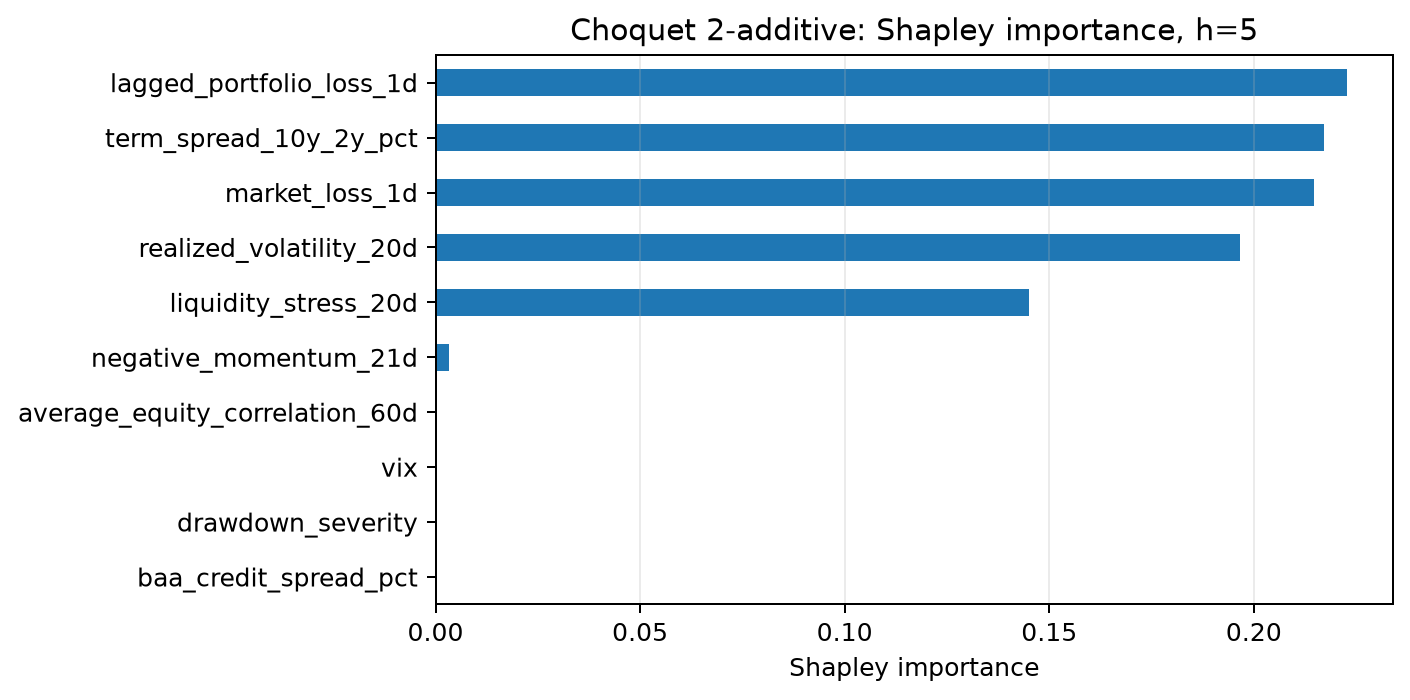

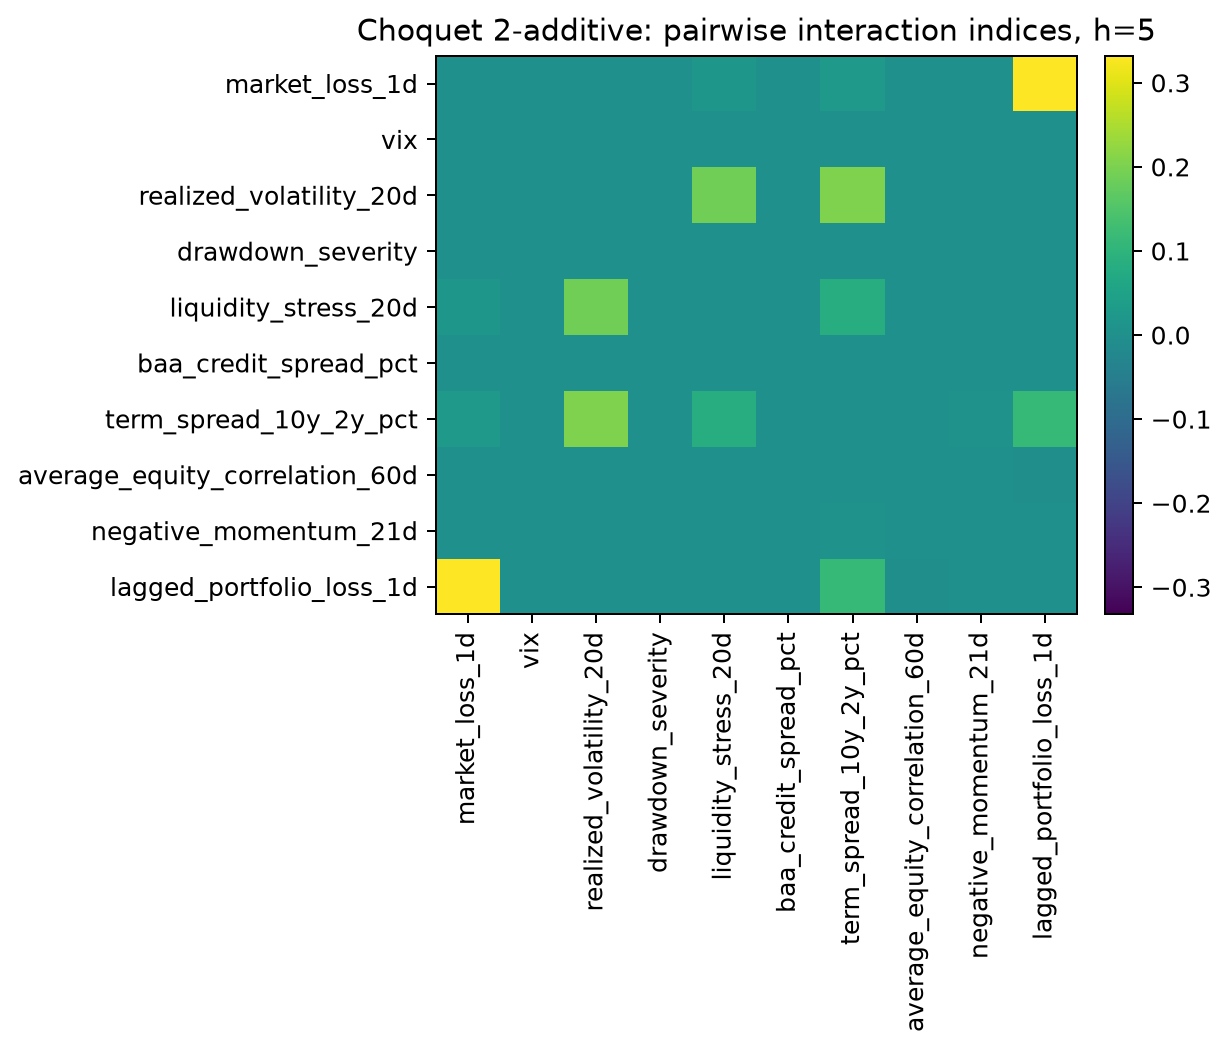

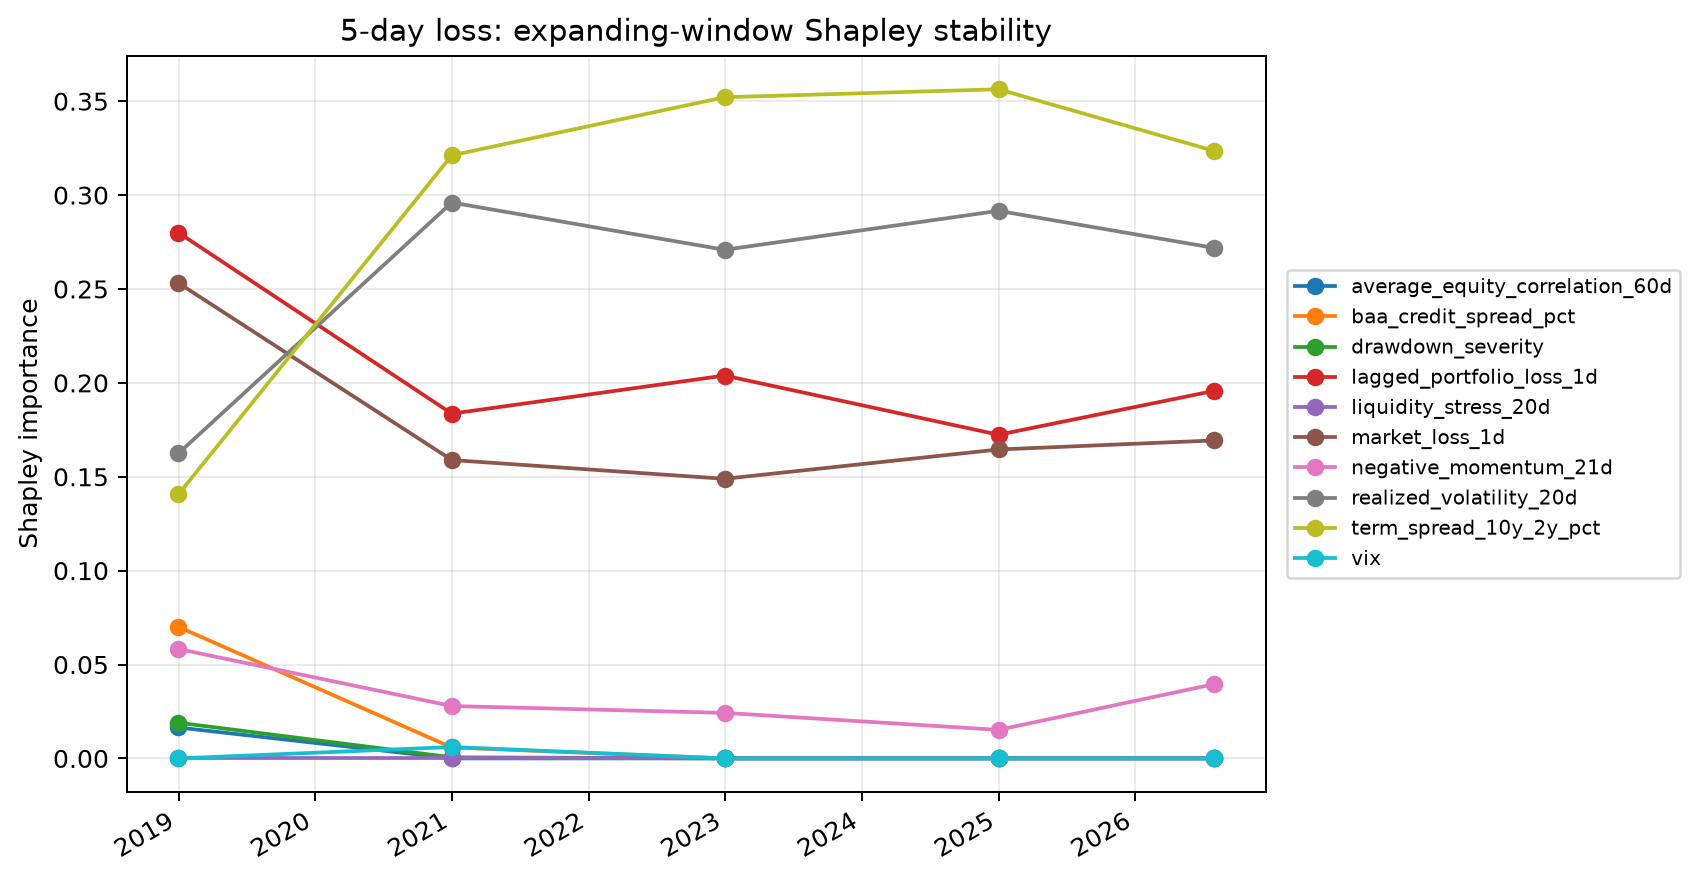

In [5]:
display(Markdown("### Final-window importance and interactions\nInterpret the latest fitted Choquet capacity through Shapley values and its strongest pairwise effects."))
display(load_result_table("experiment_2a_shapley_h5_choquet_2-additive.csv", index_col=0))
display(load_result_table("experiment_2a_top_interactions_h5_choquet_2_additive.csv"))
display(Markdown("### Expanding-sample stability\nCheck whether feature importance remains qualitatively stable as more history becomes available."))
display(load_result_table("experiment_2a_shapley_stability_h5.csv", index_col=0))
display(Markdown("### Capacity visualizations\nThe plots provide compact views of marginal importance, pairwise interaction and stability."))
display(Image(filename=result_figure_path("experiment_2a_shapley_h5_choquet_2_additive.png")))
display(Image(filename=result_figure_path("experiment_2a_interactions_h5_choquet_2_additive.png")))
display(Image(filename=result_figure_path("experiment_2a_shapley_stability_h5.png")))

## Portfolio-construction robustness

### Equal-weight versus capitalization-weight forecasts
Check whether conclusions depend on portfolio construction rather than model structure.

,equal weight,lagged market-cap weight
model,,
Historical mean,0.026190,0.031843
Monotone linear,0.026209,0.031882
Elastic net,0.027092,NaN
Lasso,0.027336,NaN
Gradient boosting,0.027414,0.033932
Ridge,0.027593,NaN
OLS oriented,0.027707,0.034390
OLS,0.027707,0.034390
Random forest,0.027773,NaN


### Choquet selection under cap weights
Identify which Choquet specification validation chooses for the alternative portfolio.

,MSE,RMSE,MAE,Tail-weighted MAE,OOS R2,Correlation,validation RMSE,selection runtime seconds,refit runtime seconds,parameter count,OOS folds
model,,,,,,,,,,,
Choquet 2-additive L1,0.001592,0.039905,0.030208,0.038474,-0.570506,-0.091933,0.037158,21.378231,5.44496,56.0,7


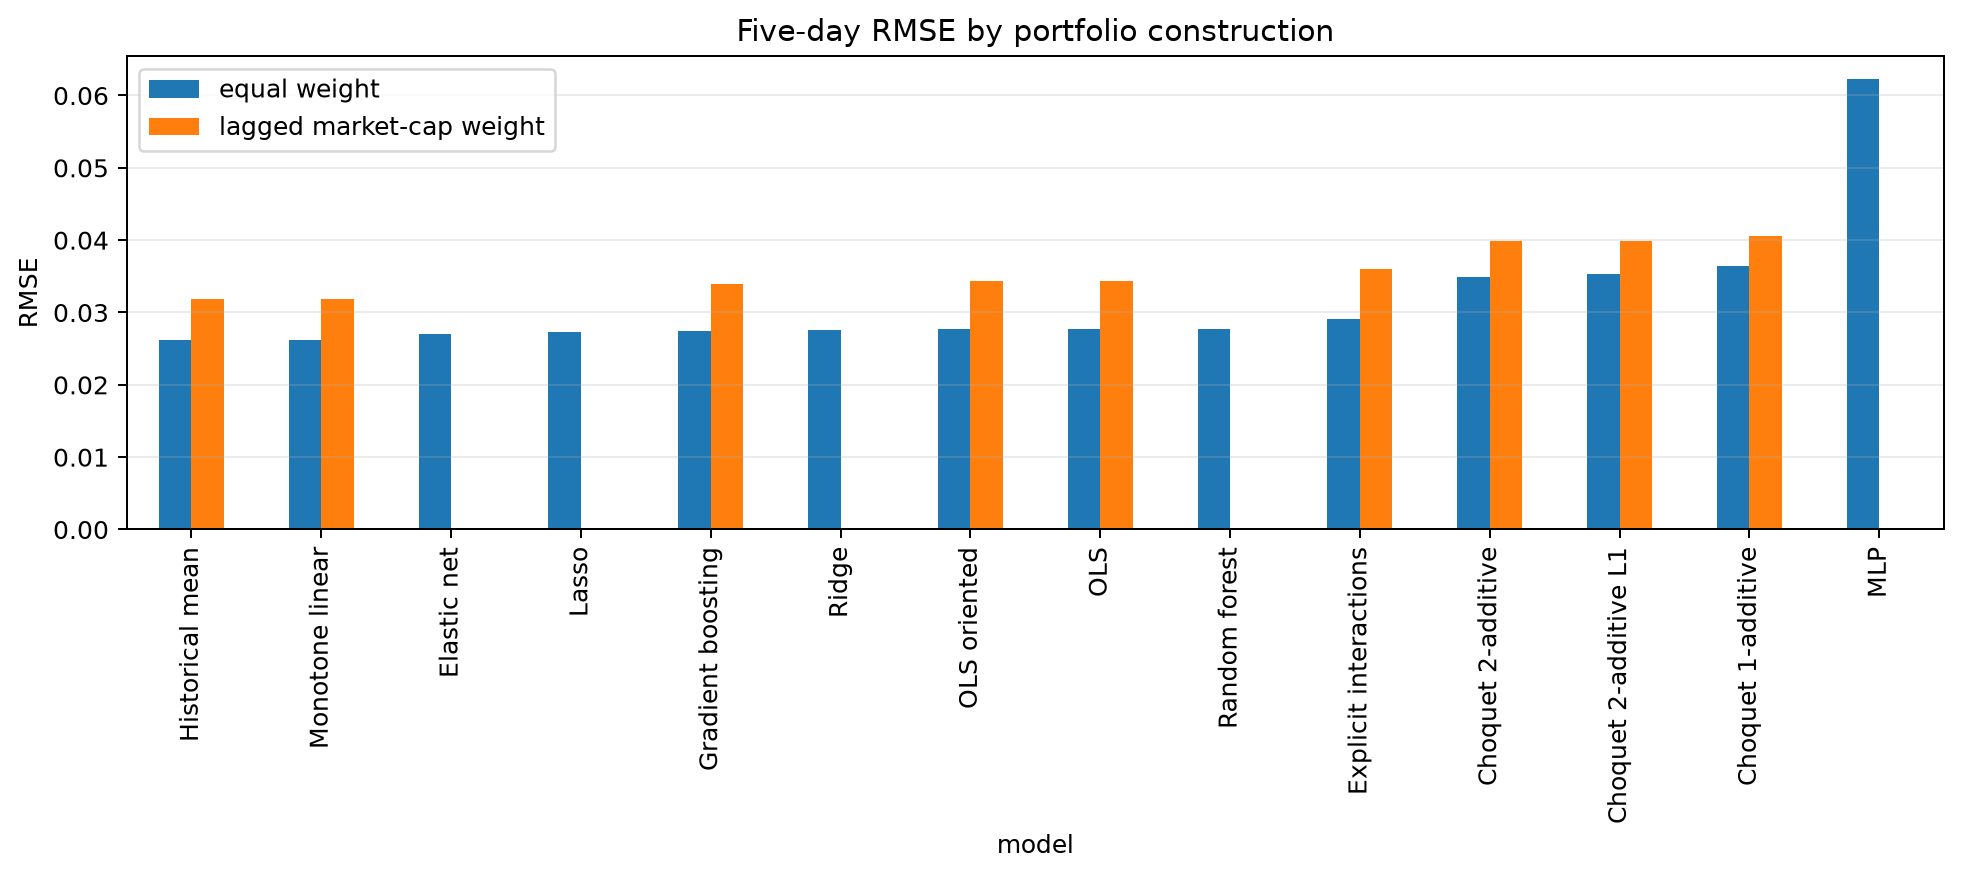

In [6]:
display(Markdown("### Equal-weight versus capitalization-weight forecasts\nCheck whether conclusions depend on portfolio construction rather than model structure."))
display(load_result_table("experiment_2a_portfolio_comparison_h5.csv", index_col=0))
display(Markdown("### Choquet selection under cap weights\nIdentify which Choquet specification validation chooses for the alternative portfolio."))
display(load_result_table("experiment_2a_cap_weight_validation_selected_choquet_h5.csv", index_col=0))
display(Image(filename=result_figure_path("experiment_2a_portfolio_robustness_h5.png")))